In [ ]:
# ===============================
# Seed Configuration (Reproducibility)
# ===============================

import random
import numpy as np
import torch

SEED = 42

# Python random seed
random.seed(SEED)

# NumPy seed
np.random.seed(SEED)

# PyTorch CPU seed
torch.manual_seed(SEED)

# PyTorch GPU seed
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")

/opt/conda/lib/python3.7/site-packages/torchvision/transforms/transforms.py:330: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  "Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. "



========== DRYWALL DATASET ==========
Train: 738
Validation: 82
Test: 202

========== CRACKS DATASET ==========
Train: 5164
Validation: 201
Test: 4

========== COMBINED DATASET ==========
Train: 5902
Validation: 283
Test: 206

Train Prompt Distribution
Counter({'segment crack': 5164, 'segment taping area': 738})

Validation Prompt Distribution
Counter({'segment crack': 201, 'segment taping area': 82})

Test Prompt Distribution
Counter({'segment taping area': 202, 'segment crack': 4})

Train Mask Distribution
{'background_pixels': 2274659589, 'object_pixels': 142799611}

Validation Mask Distribution
{'background_pixels': 105654146, 'object_pixels': 10262654}

Test Mask Distribution
{'background_pixels': 71210629, 'object_pixels': 13166971}

Showing 2 samples from Train


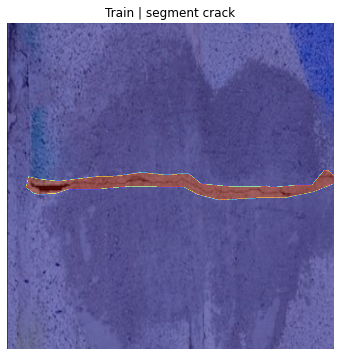

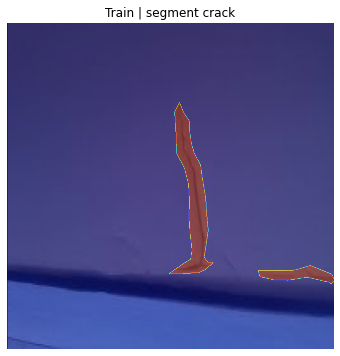


Showing 2 samples from Validation


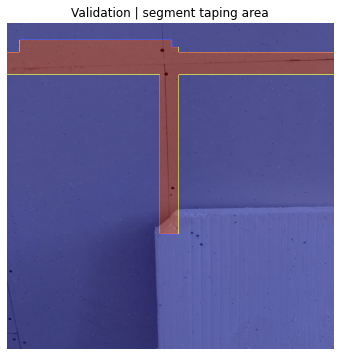

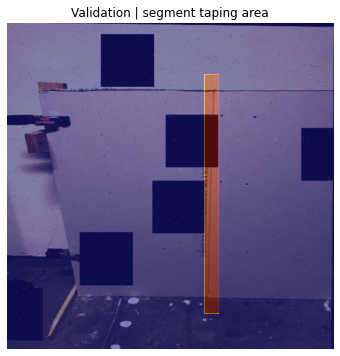


Showing 2 samples from Test


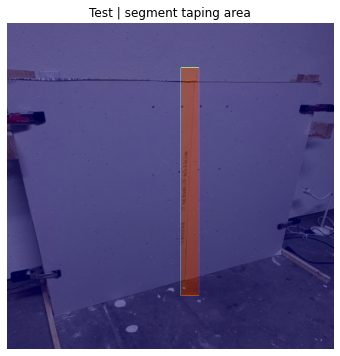

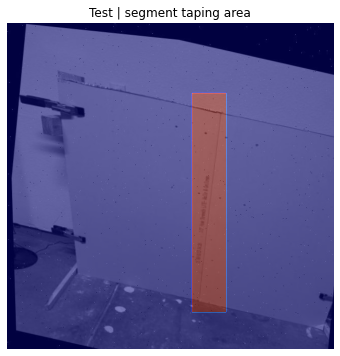

In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset, random_split
from collections import Counter
from datalaoder import COCODataset
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

def collate_fn(batch):
    return tuple(zip(*batch))


NUM_WORKERS = 4
BATCH_SIZE = 8


# -------------------------
# Drywall dataset (bbox)
# -------------------------

drywall_train_full = COCODataset(
    root_dir="Drywall-Join-Detect.coco_origin_robotics/train",
    annotation_file="Drywall-Join-Detect.coco_origin_robotics/train/_annotations.coco.json",
    annotation_type="bbox",
    prompt="segment taping area"
)

train_size = int(0.9 * len(drywall_train_full))
val_size = len(drywall_train_full) - train_size

drywall_train, drywall_val = random_split(
    drywall_train_full,
    [train_size, val_size]
)

drywall_test = COCODataset(
    root_dir="Drywall-Join-Detect.coco_origin_robotics/valid",
    annotation_file="Drywall-Join-Detect.coco_origin_robotics/valid/_annotations.coco.json",
    annotation_type="bbox",
    prompt="segment taping area"
)


# -------------------------
# Cracks dataset (polygon)
# -------------------------

cracks_train = COCODataset(
    root_dir="cracks.v1i_origin_robotics/train",
    annotation_file="cracks.v1i_origin_robotics/train/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)

cracks_val = COCODataset(
    root_dir="cracks.v1i_origin_robotics/valid",
    annotation_file="cracks.v1i_origin_robotics/valid/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)

cracks_test = COCODataset(
    root_dir="cracks.v1i_origin_robotics/test",
    annotation_file="cracks.v1i_origin_robotics/test/_annotations.coco.json",
    annotation_type="polygon",
    prompt="segment crack"
)


# -------------------------
# Combine datasets
# -------------------------

train_dataset = ConcatDataset([drywall_train, cracks_train])
val_dataset = ConcatDataset([drywall_val, cracks_val])
test_dataset = ConcatDataset([drywall_test, cracks_test])


# -------------------------
# DataLoaders
# -------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS
)


# -------------------------
# Dataset sizes
# -------------------------

print("\n========== DRYWALL DATASET ==========")
print("Train:", len(drywall_train))
print("Validation:", len(drywall_val))
print("Test:", len(drywall_test))

print("\n========== CRACKS DATASET ==========")
print("Train:", len(cracks_train))
print("Validation:", len(cracks_val))
print("Test:", len(cracks_test))

print("\n========== COMBINED DATASET ==========")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# -------------------------
# Prompt distribution
# -------------------------

def get_prompt_distribution(dataset):

    prompts = []

    for _, target in dataset:
        prompts.append(target["prompt"])

    return Counter(prompts)


print("\nTrain Prompt Distribution")
print(get_prompt_distribution(train_dataset))

print("\nValidation Prompt Distribution")
print(get_prompt_distribution(val_dataset))

print("\nTest Prompt Distribution")
print(get_prompt_distribution(test_dataset))


# -------------------------
# Mask distribution
# -------------------------

def get_mask_distribution(dataset):

    total_pixels = 0
    object_pixels = 0

    for _, target in dataset:

        mask = target["mask"]

        object_pixels += mask.sum().item()
        total_pixels += mask.numel()

    background_pixels = total_pixels - object_pixels

    return {
        "background_pixels": int(background_pixels),
        "object_pixels": int(object_pixels)
    }


print("\nTrain Mask Distribution")
print(get_mask_distribution(train_dataset))

print("\nValidation Mask Distribution")
print(get_mask_distribution(val_dataset))

print("\nTest Mask Distribution")
print(get_mask_distribution(test_dataset))


# -------------------------
# Visualization
# -------------------------

def show_samples(loader, split_name, num_samples=2):

    print(f"\nShowing {num_samples} samples from {split_name}")

    images, targets = next(iter(loader))

    for i in range(min(num_samples, len(images))):

        img = images[i].permute(1, 2, 0).numpy()
        mask = targets[i]["mask"].squeeze().numpy()
        prompt = targets[i]["prompt"]

        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.imshow(mask, alpha=0.5, cmap="jet")
        plt.title(f"{split_name} | {prompt}")
        plt.axis("off")
        plt.show()


show_samples(train_loader, "Train")
show_samples(val_loader, "Validation")
show_samples(test_loader, "Test")

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# -------------------------
# Compute dataset weights
# -------------------------

mask_stats = get_mask_distribution(train_dataset)

background_pixels = mask_stats["background_pixels"]
object_pixels = mask_stats["object_pixels"]

pos_weight_value = background_pixels / (object_pixels + 1e-6)

print("Background pixels:", background_pixels)
print("Object pixels:", object_pixels)
print("Positive weight:", pos_weight_value)

pos_weight = torch.tensor([pos_weight_value]).to(device)

Background pixels: 2274659589
Object pixels: 142799611
Positive weight: 15.929032110598564


In [3]:
import torch
import torch.nn as nn
from transformers import SegformerModel
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CLIPSegFormer(nn.Module):

    def __init__(self):

        super().__init__()

        self.segformer = SegformerModel.from_pretrained(
            "nvidia/segformer-b2-finetuned-ade-512-512"
        )

        hidden_dim = self.segformer.config.hidden_sizes[-1]

        self.clip = CLIPTextModel.from_pretrained(
            "openai/clip-vit-base-patch32"
        )

        for p in self.clip.parameters():
            p.requires_grad = False

        self.text_proj = nn.Linear(512, hidden_dim)

        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_dim, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1)
        )

    def forward(self, images, input_ids, attention_mask):

        seg_outputs = self.segformer(pixel_values=images)

        # last feature map
        feats = seg_outputs.last_hidden_state   # (B,C,H,W)

        # CLIP text encoding
        text_outputs = self.clip(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_embed = text_outputs.last_hidden_state[:,0]

        text_embed = self.text_proj(text_embed)

        text_embed = text_embed.unsqueeze(-1).unsqueeze(-1)

        fused = feats + text_embed

        mask_logits = self.decoder(fused)

        return mask_logits


tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-base-patch32"
)

model = CLIPSegFormer().to(device)

print("Model initialized successfully")

Some weights of the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 were not used when initializing SegformerModel: ['decode_head.classifier.weight', 'decode_head.batch_norm.running_var', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.3.proj.bias', 'decode_head.batch_norm.bias', 'decode_head.linear_fuse.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.0.proj.weight', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean']
- This IS expected if you are initializing SegformerModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Segforme

Model initialized successfully


In [4]:
import torch
import torch.nn.functional as F
import time
import pickle
from tqdm import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 75
LR = 1e-5

log_file = open("training_log.txt","w")

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    verbose=True
)


# -------------------------
# Loss functions
# -------------------------

def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    dice = (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice


def weighted_bce_loss(pred, target):

    return F.binary_cross_entropy_with_logits(
        pred,
        target,
        pos_weight=pos_weight
    )


def combined_loss(pred, target):

    return weighted_bce_loss(pred,target) + dice_loss(pred,target)


best_val_loss = float("inf")
best_epoch = -1

start_training_time = time.time()


# -------------------------
# Training Loop
# -------------------------

for epoch in range(EPOCHS):

    epoch_start = time.time()

    model.train()

    train_loss = 0

    pbar = tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, targets in pbar:

        images = torch.stack(images).to(device)

        masks = torch.stack(
            [t["mask"] for t in targets]
        ).to(device)

        prompts = [t["prompt"] for t in targets]

        tokenized = tokenizer(
            prompts,
            padding=True,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)

        pred = model(images, input_ids, attention_mask)

        pred = F.interpolate(
            pred,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = combined_loss(pred, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        pbar.set_postfix({"loss":loss.item()})

    train_loss /= len(train_loader)


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, targets in val_loader:

            images = torch.stack(images).to(device)

            masks = torch.stack(
                [t["mask"] for t in targets]
            ).to(device)

            prompts = [t["prompt"] for t in targets]

            tokenized = tokenizer(
                prompts,
                padding=True,
                return_tensors="pt"
            )

            input_ids = tokenized["input_ids"].to(device)
            attention_mask = tokenized["attention_mask"].to(device)

            pred = model(images, input_ids, attention_mask)

            pred = F.interpolate(
                pred,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = combined_loss(pred, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start


    log_msg = (
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Epoch Time: {epoch_time:.2f}s"
    )

    print(log_msg)

    log_file.write(log_msg+"\n")


    # -------------------------
    # Save best model
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_clip_segformer_model.pth"
        )

        metadata = {
            "best_epoch":best_epoch,
            "best_val_loss":best_val_loss
        }

        with open("best_model_info.pkl","wb") as f:
            pickle.dump(metadata,f)

        save_msg = f"Best model saved at epoch {best_epoch} with val_loss {best_val_loss:.4f}"

        print(save_msg)

        log_file.write(save_msg + "\n")   # NEW: write save event to log file


# -------------------------
# Training time
# -------------------------

total_training_time = time.time() - start_training_time

time_msg = f"\nTraining completed in {total_training_time:.2f} seconds"

print(time_msg)

log_file.write(time_msg + "\n")

log_file.close()

Epoch 1/75: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 738/738 [10:52<00:00,  1.13it/s, loss=0.785]


Epoch 1/75 | Train Loss: 1.1629 | Val Loss: 1.0865 | Epoch Time: 658.49s
Best model saved at epoch 1 with val_loss 1.0865


Epoch 2/75: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 738/738 [10:45<00:00,  1.14it/s, loss=0.943]


Epoch 2/75 | Train Loss: 0.8614 | Val Loss: 1.0568 | Epoch Time: 652.28s
Best model saved at epoch 2 with val_loss 1.0568


Epoch 3/75: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 738/738 [10:37<00:00,  1.16it/s, loss=0.817]


...

Epoch 73/75 | Train Loss: 0.3373 | Val Loss: 1.6131 | Epoch Time: 561.66s


Epoch 74/75: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 738/738 [09:10<00:00,  1.34it/s, loss=0.385]


Epoch 00074: reducing learning rate of group 0 to 1.5625e-07.
Epoch 74/75 | Train Loss: 0.3368 | Val Loss: 1.6085 | Epoch Time: 556.34s


Epoch 75/75: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 738/738 [09:13<00:00,  1.33it/s, loss=0.363]


Epoch 75/75 | Train Loss: 0.3397 | Val Loss: 1.6263 | Epoch Time: 559.48s

Training completed in 46740.85 seconds


In [5]:
import torch
import numpy as np
import cv2
import csv
import os
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading trained model...")

model.load_state_dict(
    torch.load("best_clip_segformer_model.pth", map_location=device)
)

model.eval()

# -------------------------
# Model size
# -------------------------

model_size = os.path.getsize(
    "best_clip_segformer_model.pth"
) / (1024*1024)


# -------------------------
# Metrics
# -------------------------

def dice_score(pred,target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred*target).sum()

    return (2*intersection)/(pred.sum()+target.sum()+1e-6)


def iou_score(pred,target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred*target).sum()
    union = pred.sum()+target.sum()-intersection

    return intersection/(union+1e-6)


# -------------------------
# Output folders
# -------------------------

os.makedirs("predictions",exist_ok=True)
os.makedirs("overlays",exist_ok=True)
os.makedirs("visualizations",exist_ok=True)
os.makedirs("gt_vs_pred",exist_ok=True)


dice_scores = {"segment crack":[], "segment taping area":[]}
iou_scores = {"segment crack":[], "segment taping area":[]}


csv_file = open("test_metrics.csv","w",newline="")
csv_writer = csv.writer(csv_file)

csv_writer.writerow(["image_id","prompt","dice","iou"])


print("\nRunning inference...\n")

total_start_time = time.time()
image_counter = 0


with torch.no_grad():

    for images,targets in tqdm(test_loader):

        images_tensor = torch.stack(images).to(device)

        prompts = [t["prompt"] for t in targets]
        file_names = [t["file_name"] for t in targets]

        gt_masks = torch.stack(
            [t["mask"] for t in targets]
        ).cpu().numpy()

        tokenized = tokenizer(
            prompts,
            padding=True,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device)

        batch_start = time.time()

        preds = model(images_tensor,input_ids,attention_mask)

        batch_end = time.time()

        preds = torch.sigmoid(preds)

        preds = torch.nn.functional.interpolate(
            preds,
            size=(640,640),
            mode="bilinear",
            align_corners=False
        )

        preds = (preds>0.5).float()

        preds_np = preds.cpu().numpy()
        images_np = images_tensor.cpu().numpy()


        for i in range(len(file_names)):

            pred_mask = preds_np[i][0]
            gt_mask = gt_masks[i][0]

            dice = dice_score(pred_mask,gt_mask)
            iou = iou_score(pred_mask,gt_mask)

            prompt = prompts[i]

            dice_scores[prompt].append(dice)
            iou_scores[prompt].append(iou)

            image_id = file_names[i].split(".")[0]
            prompt_name = prompt.replace(" ","_")

            csv_writer.writerow([image_id,prompt,dice,iou])

            binary_mask = (pred_mask*255).astype(np.uint8)

            # -------------------------
            # Original Image
            # -------------------------

            image = images_np[i].transpose(1,2,0)
            image = (image*255).astype(np.uint8)

            # -------------------------
            # Overlay
            # -------------------------

            color_mask = cv2.applyColorMap(
                binary_mask,
                cv2.COLORMAP_JET
            )

            overlay = cv2.addWeighted(
                image,
                0.7,
                color_mask,
                0.3,
                0
            )

            # -------------------------
            # Save mask
            # -------------------------

            cv2.imwrite(
                f"predictions/{image_id}__{prompt_name}.png",
                binary_mask
            )

            cv2.imwrite(
                f"overlays/{image_id}__{prompt_name}_overlay.png",
                overlay
            )


            # -------------------------
            # Visualization (single plot)
            # -------------------------

            fig,axes = plt.subplots(1,3,figsize=(15,5))

            axes[0].imshow(image)
            axes[0].set_title("Original")
            axes[0].axis("off")

            axes[1].imshow(binary_mask,cmap="gray")
            axes[1].set_title("Predicted Mask")
            axes[1].axis("off")

            axes[2].imshow(overlay)
            axes[2].set_title("Overlay")
            axes[2].axis("off")

            plt.tight_layout()

            plt.savefig(
                f"visualizations/{image_id}__{prompt_name}_viz.png"
            )

            plt.close()


            # -------------------------
            # GT vs Prediction comparison
            # -------------------------

            fig,axes = plt.subplots(1,2,figsize=(10,5))

            axes[0].imshow(gt_mask,cmap="gray")
            axes[0].set_title("Ground Truth")
            axes[0].axis("off")

            axes[1].imshow(binary_mask,cmap="gray")
            axes[1].set_title("Prediction")
            axes[1].axis("off")

            plt.tight_layout()

            plt.savefig(
                f"gt_vs_pred/{image_id}__{prompt_name}_comparison.png"
            )

            plt.close()

            image_counter += 1


# -------------------------
# Timing
# -------------------------

total_time = time.time() - total_start_time
avg_time = total_time / image_counter


# -------------------------
# Final Metrics
# -------------------------

summary_file = open("test_summary.txt","w")

print("\n==============================")
print("Inference Completed")
print("==============================")

for prompt in dice_scores.keys():

    mean_dice = np.mean(dice_scores[prompt])
    mean_iou = np.mean(iou_scores[prompt])

    print(f"\nPrompt: {prompt}")
    print(f"Mean Dice: {mean_dice:.4f}")
    print(f"Mean mIoU: {mean_iou:.4f}")

    summary_file.write(f"{prompt}\n")
    summary_file.write(f"Mean Dice: {mean_dice:.4f}\n")
    summary_file.write(f"Mean mIoU: {mean_iou:.4f}\n\n")

summary_file.close()
csv_file.close()


# -------------------------
# Model Statistics
# -------------------------

stats_file = open("model_stats.csv","w",newline="")
writer = csv.writer(stats_file)

writer.writerow([
    "Model",
    "Model Size (MB)",
    "Avg Inference Time / Image (s)",
    "Total Inference Time (s)"
])

writer.writerow([
    "CLIP + SegFormer",
    round(model_size,2),
    round(avg_time,4),
    round(total_time,2)
])

stats_file.close()


print("\nModel Statistics")
print("----------------------------")
print("Model Size (MB):",round(model_size,2))
print("Avg Time / Image:",round(avg_time,4))
print("Total Time:",round(total_time,2))


print("\nOutputs saved:")
print("Binary masks → predictions/")
print("Overlays → overlays/")
print("Visualizations → visualizations/")
print("GT vs Pred → gt_vs_pred/")
print("Metrics → test_metrics.csv")
print("Summary → test_summary.txt")
print("Model stats → model_stats.csv")

Loading trained model...

Running inference...



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [01:58<00:00,  4.57s/it]


Inference Completed

Prompt: segment crack
Mean Dice: 0.4852
Mean mIoU: 0.3604

Prompt: segment taping area
Mean Dice: 0.6869
Mean mIoU: 0.5389

Model Statistics
----------------------------
Model Size (MB): 339.55
Avg Time / Image: 0.5772
Total Time: 118.9

Outputs saved:
Binary masks → predictions/
Overlays → overlays/
Visualizations → visualizations/
GT vs Pred → gt_vs_pred/
Metrics → test_metrics.csv
Summary → test_summary.txt
Model stats → model_stats.csv
